## Gene embedding analysis 
### subset of 2k - adipocytes

In [1]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [2]:
main_path1 = "/rds/general/user/ap5625/home/perturbation_modeling"

main_path = "/rds/general/user/ap5625/home/perturbation_modeling/perturbGEN/subset_2k_adipocytes/"
input_path = "/rds/general/project/lms-scott-raw/live/Ada/perturbation_modeling/T_perturb/res/masking/"

input_path2 = "/rds/general/user/ap5625/projects/lms-scott-raw/live/Ada/perturbation_modeling"

In [3]:
adata = sc.read_h5ad(
    input_path + "20260612-22:02_inference_embs_t[1]_scmaskgit_mpow.h5ad"
)

In [4]:
adata

AnnData object with n_obs × n_vars = 1024 × 1462
    obs: 'cell_pairing_index', 'cell_states_adipocytes', 'condition', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: 'weightloss'

In [17]:
print(f"Cell embeddings shape: {adata.obsm['cls_embeddings'].shape}")
print(f"Gene embeddings shape: {adata.varm['weightloss'].shape}")
print(f"Conditions: {adata.obs['condition'].value_counts()}")
print(f"Cell states: {adata.obs['cell_states_adipocytes'].value_counts()}")

Cell embeddings shape: (1024, 768)
Gene embeddings shape: (1462, 768)
Conditions: condition
weightloss    1024
Name: count, dtype: int64
Cell states: cell_states_adipocytes
AD2            416
AD1            215
AD4            113
AD3            103
AD6             70
AD9             34
AD5_basal       28
AD5_BMPERhi     22
AD8             12
AD7             11
Name: count, dtype: int64


In [18]:
print(adata.varm.keys())

KeysView(AxisArrays with keys: weightloss)


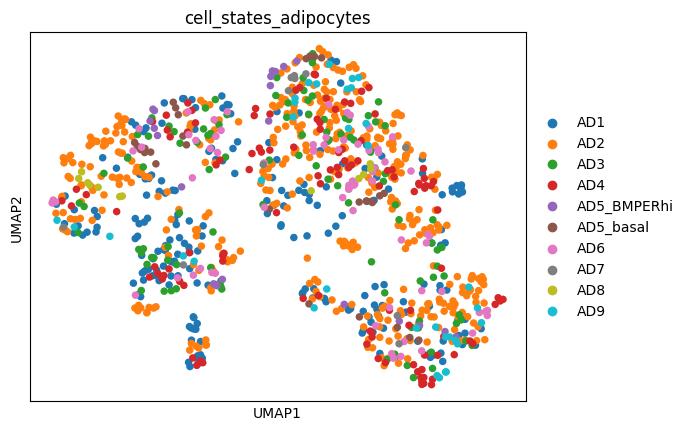

In [15]:
sc.pp.neighbors(
    adata, use_rep="cls_embeddings"
)  # compute the neighborhood graph
sc.tl.umap(adata)  # compute the UMAP coordinates
sc.pl.umap(
    adata, color="cell_states_adipocytes"
)  # plot the UMAP with cell type coloring

In [4]:
adata_full = sc.read_h5ad(input_path2 + "/adipocytes_subset_2k.h5ad")

adata_full.X = adata_full.layers["raw"].copy()

In [5]:
adata_full.X.max()

np.float32(463.0)

In [6]:
sc.pp.normalize_total(adata_full)  # normalize the data
sc.pp.log1p(adata_full)  # log-transform the data

In [7]:
sc.pp.neighbors(adata_full)  # compute the neighborhood graph
sc.tl.umap(adata_full)  # compute the UMAP coordinates

/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
adata_full

AnnData object with n_obs × n_vars = 2000 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'barcodes', 'condition', 'remission', 't2d_batch', 'n_genes', 'count_keep', 'mt_keep', 'rb_keep', 'doublet_keep', 'study', 'pooled_donors', 'SeqID', 'cellID', 'Donor', 'sample', 'Chemistry', 'pool_barcodes', 'dataset', 'BMI', 'sex', 'mt.percent', 'ribo.percent', 'emont_cell_type', 'emont_cell_type2', 'cell_type_level1', 'cell_type_level2', 'cell_state', 'subUMAP1_v1', 'subUMAP2_v1', 'subUMAP1_v2', 'subUMAP2_v2', 'New_donor', 'new_sample', 'UMAPglobal_x', 'UMAPglobal_y', 'orig_barcodes', 'miranda_barcodes', 'leiden_0.1', 'leiden_0.15', 'leiden_0.25', 'leiden_0.5

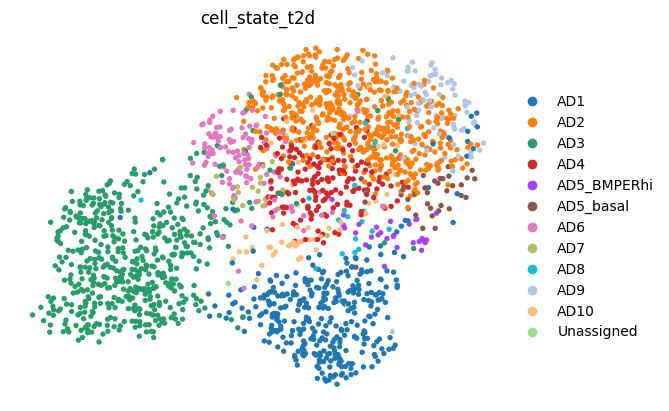

In [9]:
sc.pl.umap(  # plot UMAP of full data
    adata_full, color="cell_state_t2d", frameon=False, save="_umapcelltype.png"
)

## Map gene symbols to ensemble IDS 

In [10]:
print(adata.var.columns.tolist())
print(adata.var.head())

['token_id']
                 token_id
ENSG00000174611         0
ENSG00000139352         1
ENSG00000134242         2
ENSG00000081800         3
ENSG00000095564         4


In [11]:
print(adata_full.var.columns.tolist())
print(adata_full.var.head())

['highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std']
            highly_variable         means  dispersions  dispersions_norm  \
GABPB1-AS1            False  2.319541e-01     1.476932         -0.253013   
LINC00705             False  2.501364e-03     1.650039         -0.098541   
KY                    False  1.350673e-02     1.535456         -0.119745   
ASCL1                 False  9.746840e-07     1.214197         -1.123107   
LARS2-AS1             False  1.562263e-02     1.616517          0.040035   

            highly_variable_nbatches  highly_variable_intersection  \
GABPB1-AS1                         0                         False   
LINC00705                          0                         False   
KY                                 0                         False   
ASCL1                              0                         False   
LARS2-AS1                          0                  

In [12]:
# creating gene symbol columns
adata.var["gene_symbol"] = adata.var_names.tolist()

In [13]:
adata_full.var["gene_symbol"] = adata_full.var_names.tolist()

In [14]:
# map gene symbols in original to ENSEMBL ID s

ref = pd.read_csv(main_path1 + "/mart_export.txt", sep="\t")

print(ref.columns.tolist())

['Gene stable ID', 'Gene name']


In [15]:
# You already have symbol_to_ensembl from before
# Just reverse it to get ensembl_to_symbol
ensembl_to_symbol = dict(zip(ref["Gene stable ID"], ref["Gene name"]))

adata.var["gene_symbol"] = adata.var_names.map(ensembl_to_symbol)

print(f"Mapped: {adata.var['gene_symbol'].notna().sum()} / {adata.n_vars}")
print(adata.var.head(10))

Mapped: 1462 / 1462
                 token_id gene_symbol
ENSG00000174611         0          KY
ENSG00000139352         1       ASCL1
ENSG00000134242         2      PTPN22
ENSG00000081800         3     SLC13A1
ENSG00000095564         4       BTAF1
ENSG00000153147         5     SMARCA5
ENSG00000268182         6      SMIM17
ENSG00000132972         7       RNF17
ENSG00000205330         8       OR6C1
ENSG00000134909         9    ARHGAP32


## construct a new AnnData object in which each gene is treated as an observation (analogous to a cell), and its features correspond to a n(here =768)-dimensional learned embedding vector rather than expression values
- to perform standard single cell workflows

In [16]:
gene_symbols = adata.var["gene_symbol"].values
timepoints = list(adata.varm.keys())  # in only have WL in this case

In [17]:
all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]
    all_embeddings.append(embedding)

    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame(
    {"gene_symbol": obs_genes, "timepoint": obs_timepoints}, index=obs_names
)

new_adata = ad.AnnData(X=X, obs=obs)

## identify gene–timepoint vectors whose embedding values are all zero and report how many such cases exist.

In [18]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")

Number of gene-timepoint vectors with all-zero values: 245


In [19]:
new_adata = new_adata[~zero_mask].copy()  # Remove all-zero embeddings.
print(new_adata)

AnnData object with n_obs × n_vars = 1217 × 768
    obs: 'gene_symbol', 'timepoint'


In [20]:
sc.pp.neighbors(new_adata)  # compute the neighborhood graph
sc.tl.umap(new_adata)  # compute the UMAP coordinates

/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


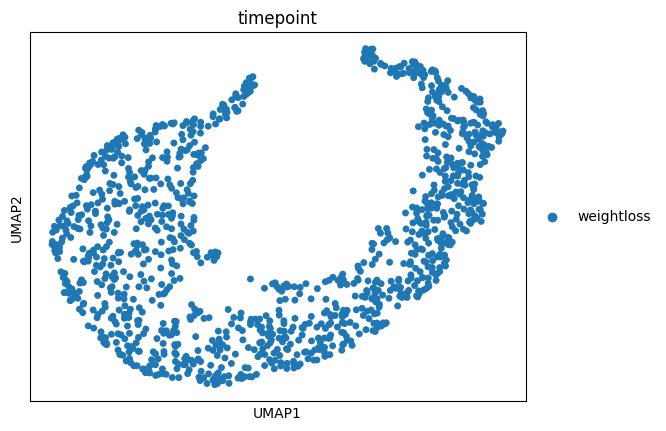

In [21]:
sc.pl.umap(new_adata, color="timepoint")

In [22]:
# cluster the gene embeddings

sc.tl.leiden(new_adata, resolution=1, key_added="r1")  # cluster gene embeddings

/var/tmp/pbs.3111577.pbs-7/ipykernel_2180076/679499853.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings


In [23]:
results = {}

for cluster in new_adata.obs["r1"].unique():
    cluster_genes = new_adata.obs.loc[
        new_adata.obs["r1"] == cluster, "gene_symbol"
    ].tolist()

    enr = gp.enrichr(
        gene_list=cluster_genes,
        gene_sets=["GO_Biological_Process_2025", "Reactome_Pathways_2024"],
        organism="Human",
        outdir=None,
        cutoff=0.5,
    )

    results[cluster] = enr.results.sort_values("Adjusted P-value").head(5)

In [24]:
print(new_adata)

AnnData object with n_obs × n_vars = 1217 × 768
    obs: 'gene_symbol', 'timepoint', 'r1'
    uns: 'pca', 'neighbors', 'umap', 'timepoint_colors', 'r1'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


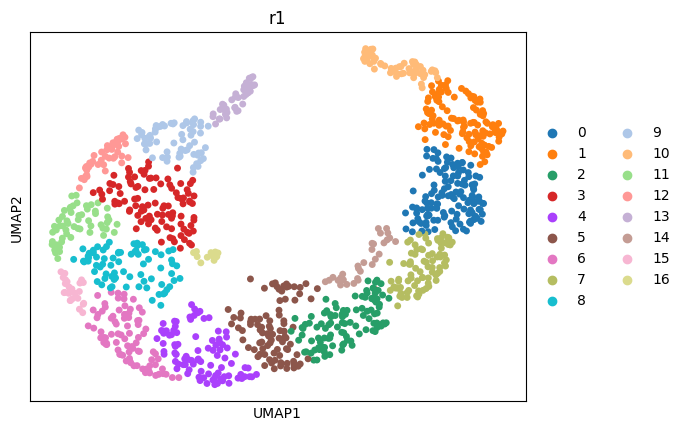

In [25]:
sc.pl.umap(new_adata, color="r1")

/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/rds/general/user/ap5625/home/miniforge3/envs/perturbgen/lib/python3.11/site-pac

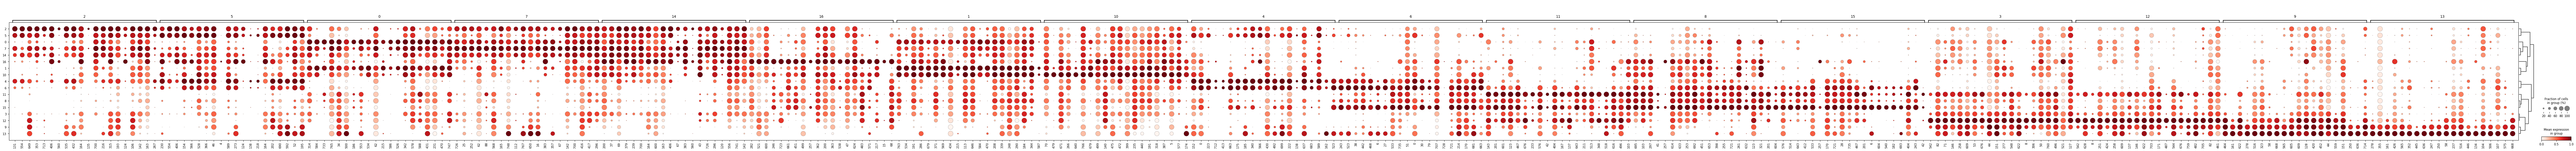

In [75]:
sc.tl.rank_genes_groups(new_adata, groupby="r1", method="t-test_overestim_var")
sc.pl.rank_genes_groups_dotplot(
    new_adata,
    groupby="r1",
    standard_scale="var",
    n_genes=20,
    save="perturbgen_r1_adipocytes2k.png",
)

## this didnt work - because in this AnnData object the structure has been flipped - genes are observation (rows) - and var_names are indices of the vector 

In [26]:
# See genes per cluster
for cluster in new_adata.obs["r1"].unique():
    genes = new_adata.obs.loc[
        new_adata.obs["r1"] == cluster, "gene_symbol"
    ].tolist()
    print(f"\nCluster {cluster} ({len(genes)} genes):")
    print(genes[:10])  # show first 10 genes


Cluster 10 (59 genes):
['KY', 'ARHGEF16', 'SDSL', 'OXSM', 'ERCC6L', 'OOSP3', 'GCM2', 'TSPAN16', 'PRRG2', 'ZNF768']

Cluster 8 (76 genes):
['PTPN22', 'SMARCA5', 'LONP2', 'CD302', 'CNOT2', 'KIF6', 'CNPY2', 'COMMD1', 'ICE1', 'TLE1']

Cluster 3 (103 genes):
['BTAF1', 'ARHGAP32', 'NCOA1', 'MAFB', 'BLTP1', 'BAZ2B', 'IGFBP5', 'H2AJ', 'C4BPA', 'SMAP1']

Cluster 7 (83 genes):
['SMIM17', 'TRAF6', 'DMAC2L', 'TSKS', 'SERPIND1', 'GALNT14', 'IQSEC3', 'EIF2D', 'SLC25A38', 'ZFPM1']

Cluster 1 (118 genes):
['RNF17', 'PIP5K1C', 'RIOX2', 'SPOUT1', 'MAS1', 'ALDH8A1', 'SHCBP1', 'PPEF1', 'FLRT1', 'PLA2G12B']

Cluster 2 (104 genes):
['INTS11', 'TTC21A', 'COLEC11', 'PPIF', 'TRIB3', 'GPRC5D', 'ZNF281', 'ZNF440', 'SLC39A5', 'ANKRD50']

Cluster 5 (91 genes):
['CENPE', 'WNT8B', 'ZNF417', 'HIBADH', 'PYGL', 'PEBP4', 'IFT80', 'MED6', 'NDUFAF6', 'GATA6']

Cluster 0 (130 genes):
['IGHMBP2', 'ZNF461', 'NIT2', 'GEMIN5', 'TRIM41', 'GOLGA7B', 'NKIRAS2', 'GTF3C5', 'POMK', 'GFPT2']

Cluster 9 (64 genes):
['PAK5', 'DUSP1', 

In [27]:
results = {}

for cluster in new_adata.obs["r1"].unique():
    cluster_genes = new_adata.obs.loc[
        new_adata.obs["r1"] == cluster, "gene_symbol"
    ].tolist()

    enr = gp.enrichr(  # perform gene set enrichment analysis
        gene_list=cluster_genes,
        gene_sets=["GO_Biological_Process_2025", "Reactome_Pathways_2024"],
        organism="Human",
        outdir=None,
        cutoff=0.5,
    )

    results[cluster] = enr.results.sort_values("Adjusted P-value").head(
        5
    )  # store top 5 results per cluster

In [28]:
for cluster in sorted(results.keys()):
    print(f"\n=== Cluster {cluster} ===")
    print(
        results[cluster][["Gene_set", "Term", "Adjusted P-value"]].to_string(
            index=False
        )
    )


=== Cluster 0 ===
                  Gene_set                                                                             Term  Adjusted P-value
GO_Biological_Process_2025                           Regulation of DNA-templated Transcription (GO:0006355)          0.060347
GO_Biological_Process_2025                    Regulation of Transcription by RNA Polymerase II (GO:0006357)          0.072905
GO_Biological_Process_2025                                               DNA Metabolic Process (GO:0006259)          0.177375
GO_Biological_Process_2025 Positive Regulation of Type I Interferon-Mediated Signaling Pathway (GO:0060340)          0.272021
GO_Biological_Process_2025                                               Wnt Signaling Pathway (GO:0016055)          0.272021

=== Cluster 1 ===
                  Gene_set                                                  Term  Adjusted P-value
    Reactome_Pathways_2024                                              Kinesins          0.164755
GO_Biolo

In [29]:
# Compile top term per cluster into a dataframe
summary = []
for cluster, df in results.items():
    if len(df) > 0:
        top = df.iloc[0]
        summary.append(
            {
                "Cluster": cluster,
                "Top Term": top["Term"],
                "Adjusted P-value": top["Adjusted P-value"],
                "Gene_set": top["Gene_set"],
            }
        )

summary_df = pd.DataFrame(summary).sort_values("Cluster")
print(summary_df.to_string(index=False))

Cluster                                                                      Top Term  Adjusted P-value                   Gene_set
      0                        Regulation of DNA-templated Transcription (GO:0006355)          0.060347 GO_Biological_Process_2025
      1                                                                      Kinesins          0.164755     Reactome_Pathways_2024
     10                                         Muscle Organ Development (GO:0007517)          0.183707 GO_Biological_Process_2025
     11                                                 Defective CSF2RA Causes SMDP4          0.030393     Reactome_Pathways_2024
     12                                  U2-type Prespliceosome Assembly (GO:1903241)          0.000050 GO_Biological_Process_2025
     13           Negative Regulation of Rho Protein Signal Transduction (GO:0035024)          0.003259 GO_Biological_Process_2025
     14 Defective Homologous Recombination Repair (HRR) Due to PALB2 Loss of Functi

In [33]:
ref[ref["Gene name"] == "GFPT2"][["Gene name", "Gene stable ID"]]

,Gene name,Gene stable ID
80153,GFPT2,ENSG00000131459


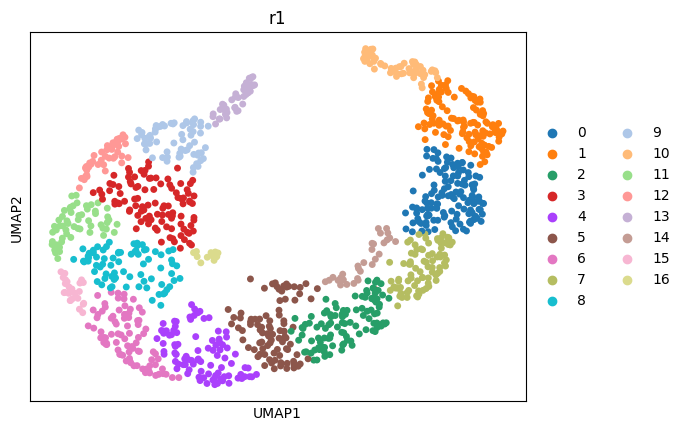

In [86]:
sc.pl.umap(new_adata, color="r1")

In [31]:
ref[ref["Gene name"] == "NAMPT"][["Gene name", "Gene stable ID"]]

,Gene name,Gene stable ID
85225,NAMPT,ENSG00000105835
